In [1]:
!pip install pandas matplotlib numpy





[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
gen   = pd.read_csv('generation_mix.csv',   parse_dates=['datetime'])
prices = pd.read_csv('power_prices.csv',    parse_dates=['datetime'])
comm  = pd.read_csv('commodity_prices.csv', parse_dates=['date'])

print("generation_mix shape  :", gen.shape)
print("power_prices shape    :", prices.shape)
print("commodity_prices shape:", comm.shape)

generation_mix shape  : (146082, 11)
power_prices shape    : (146085, 11)
commodity_prices shape: (3653, 9)


In [4]:
#Exploring the generation_mix data 
print(" First 5 rows ")
print(gen.head())

print("\n Column names and data types ")
gen.info()

print("\n Which countries are in the data? ")
print(gen['zone'].unique())

print("\n Date range")
print("From:", gen['datetime'].min())
print("To  :", gen['datetime'].max())

print("\n Any missing values? ")
print(gen.isnull().sum())

 First 5 rows 
             datetime zone  nuclear_mw  hydro_mw  wind_mw  solar_mw  gas_mw  \
0 2015-01-01 00:00:00   DE        10.3       2.6     11.4       0.8    33.3   
1 2015-01-01 03:00:00   DE         9.4       2.4     10.0       0.4    30.8   
2 2015-01-01 06:00:00   DE        10.3       2.6     10.3       0.5    34.0   
3 2015-01-01 09:00:00   DE        11.7       2.9     14.6       0.0    37.5   
4 2015-01-01 12:00:00   DE        10.4       2.6     14.0       0.8    32.5   

   coal_mw  other_mw  total_mw  renewables_pct  
0     18.2       9.1      85.7           17.28  
1     16.8       8.4      78.2           16.29  
2     18.6       9.3      85.5           15.63  
3     20.4      10.2      97.3           18.00  
4     17.7       8.9      87.0           20.02  

 Column names and data types 
<class 'pandas.DataFrame'>
RangeIndex: 146082 entries, 0 to 146081
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          -----------

In [6]:
#  Exploring commodity prices
# This tells us how much gas, coal and carbon COST each day
# These costs are what we use to calculate the merit order

print("Commodity prices - first 5 rows ")
print(comm.head())

print("\n Column names ")
print(comm.columns.tolist())

print("\n Yearly average gas price ")
comm['year'] = comm['date'].dt.year
yearly = comm.groupby('year')[['gas_price_eur_mwh',
                                'coal_price_usd_t',
                                'carbon_price_eur_t']].mean().round(1)
print(yearly)

Commodity prices - first 5 rows 
        date  gas_price_eur_mwh  coal_price_usd_t  carbon_price_eur_t  \
0 2015-01-01             20.000            80.000              25.000   
1 2015-01-02             20.152            78.752              25.375   
2 2015-01-03             19.169            77.214              25.440   
3 2015-01-04             19.161            76.226              25.888   
4 2015-01-05             19.193            77.515              26.130   

   oil_price_usd_bbl  spark_spread  dark_spread  clean_spark_spread  \
0             60.000        -7.647      -49.167              12.353   
1             61.016        -7.779      -49.712              12.521   
2             60.668        -7.921      -50.027              12.431   
3             61.518        -8.101      -50.594              12.609   
4             60.566        -8.194      -50.598              12.710   

  shock_event  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  

 Col

In [18]:
print('Gas price range:', comm['gas_price_eur_mwh'].min().round(1), 'to', comm['gas_price_eur_mwh'].max().round(1))
print('Gas peak date:', comm.loc[comm['gas_price_eur_mwh'].idxmax(), 'date'])

Gas price range: 5.7 to 350.0
Gas peak date: 2022-03-01 00:00:00


In [16]:
#exploring power prices
print(" First 5 rows ")
print(prices.head())

print("\n Column names and data types ")
prices.info()

print("\n Which countries are in the data? ")
print(prices['zone'].unique())

print("\n Date range ")
print("From:", prices['datetime'].min())
print("To  :", prices['datetime'].max())

print("\n  missing values")
print(prices.isnull().sum())

print("\n Price statistics (all zones) ")
print(prices['price_eur_mwh'].describe().round(2))

 First 5 rows 
             datetime        date  hour zone  price_eur_mwh  demand_mw  \
0 2015-01-01 00:00:00  2015-01-01     0   DE         25.331       85.7   
1 2015-01-01 03:00:00  2015-01-01     3   DE         22.700       78.2   
2 2015-01-01 06:00:00  2015-01-01     6   DE         20.039       85.5   
3 2015-01-01 09:00:00  2015-01-01     9   DE         23.121       97.3   
4 2015-01-01 12:00:00  2015-01-01    12   DE         27.211       87.0   

   wind_cf  solar_cf  net_demand_frac  is_negative_price shock_event  
0   0.3000    0.0375           0.6760                  0         NaN  
1   0.2623    0.0183           0.6234                  0         NaN  
2   0.2701    0.0233           0.6872                  0         NaN  
3   0.3832    0.0000           0.7609                  0         NaN  
4   0.3679    0.0366           0.6642                  0         NaN  

 Column names and data types 
<class 'pandas.DataFrame'>
RangeIndex: 146085 entries, 0 to 146084
Data columns (to

In [ ]:
# Filtering only Germany (zone = 'DE')

gen_de    = gen[gen['zone'] == 'DE'].copy()
prices_de = prices[prices['zone'] == 'DE'].copy()

print("Germany generation rows:", len(gen_de))
print("Germany price rows     :", len(prices_de))

# Look at one week of data to understand it
one_week = gen_de[gen_de['datetime'].dt.date == pd.Timestamp('2023-01-18').date()]
print("\nOne day snapshot:")
print(one_week[['datetime','nuclear_mw','wind_mw','solar_mw','gas_mw','coal_mw','total_mw']])

In [30]:
# Calculating marginal costs for each fuel type
# We calculate: how much does it cost to produce 1 MWh from each fuel?

# Why we divide gas price by 0.50:
# A gas plant is only 50% efficient — it burns 2 units of gas
# to produce 1 unit of electricity. The other unit is waste heat.
# So if gas costs 20 EUR/MWh of fuel, you need 40 EUR worth
# of gas to make 1 MWh of electricity.
#
# Why we add carbon cost:
# EU law says power plants must buy a carbon permit for every
# tonne of CO2 they emit. Gas emits 0.20 tCO2 per MWh.
# Coal emits 0.85 tCO2 per MWh (much dirtier).
# So when carbon price is high, coal becomes very expensive.

USD_TO_EUR = 0.92   # approximate exchange rate

def calc_marginal_costs(gas_eur_mwh, coal_usd_t, carbon_eur_t):
    """
    Given today's commodity prices, calculate the marginal cost
    of each fuel type in EUR/MWh.
    
    This function takes 3 inputs:
      gas_eur_mwh   = gas price in EUR per MWh
      coal_usd_t    = coal price in USD per tonne
      carbon_eur_t  = carbon permit price in EUR per tonne CO2
    
    And returns a dictionary with cost for each fuel.
    """
    
    # COAL marginal cost
    # Step 1: convert coal from USD/tonne to EUR/MWh
    #         1 tonne of coal produces ~8 MWh of thermal energy
    coal_fuel_cost   = (coal_usd_t / 8.0) * USD_TO_EUR
    # Step 2: add carbon cost (coal is dirty — 0.85 tCO2 per MWh)
    coal_carbon_cost = 0.85 * carbon_eur_t
    coal_mc          = coal_fuel_cost + coal_carbon_cost
    
    # GAS marginal cost
    # Step 1: gas plant is 50% efficient, so divide by 0.50
    gas_fuel_cost    = gas_eur_mwh / 0.50
    # Step 2: add carbon cost (gas is cleaner — 0.20 tCO2 per MWh)
    gas_carbon_cost  = 0.20 * carbon_eur_t
    gas_mc           = gas_fuel_cost + gas_carbon_cost
    
    return {
        'wind'   : 0.0,          # fuel is free
        'solar'  : 0.0,          # fuel is free
        'hydro'  : 2.0,          # just opportunity cost of water
        'nuclear': 5.0,          # uranium is very cheap
        'coal'   : round(coal_mc, 1),
        'gas'    : round(gas_mc,  1),
        'other'  : 40.0,
    }

# testing this function with real numbers 

# Get average prices for 3 key years from our data
for year, label in [(2019, '2019  NORMAL MARKET'),
                    (2022, '2022  GAS CRISIS   '),
                    (2024, '2024  RECOVERY     ')]:
    
 # calculate average commodity prices for that year
    year_data = comm[comm['year'] == year]
    avg_gas   = year_data['gas_price_eur_mwh'].mean()
    avg_coal  = year_data['coal_price_usd_t'].mean()
    avg_carbon= year_data['carbon_price_eur_t'].mean()
    
 #  formula
    mc = calc_marginal_costs(avg_gas, avg_coal, avg_carbon)
    
    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"  Gas input price : {avg_gas:.1f} EUR/MWh")
    print(f"  Carbon price    : {avg_carbon:.1f} EUR/tonne")
    print(f"{'='*45}")
    print(f"  Fuel          Cost (EUR/MWh)")
    print(f"  ----------    -------------")
    for fuel, cost in mc.items():
        bar = '█' * int(cost / 10)   # visual bar
        print(f"  {fuel:<10}    {cost:>6.1f}   {bar}")


  2019  NORMAL MARKET
  Gas input price : 21.9 EUR/MWh
  Carbon price    : 11.1 EUR/tonne
  Fuel          Cost (EUR/MWh)
  ----------    -------------
  wind             0.0   
  solar            0.0   
  hydro            2.0   
  nuclear          5.0   
  coal            18.3   █
  gas             46.1   ████
  other           40.0   ████

  2022  GAS CRISIS   
  Gas input price : 269.6 EUR/MWh
  Carbon price    : 66.0 EUR/tonne
  Fuel          Cost (EUR/MWh)
  ----------    -------------
  wind             0.0   
  solar            0.0   
  hydro            2.0   
  nuclear          5.0   
  coal            63.0   ██████
  gas            552.4   ███████████████████████████████████████████████████████
  other           40.0   ████

  2024  RECOVERY     
  Gas input price : 46.3 EUR/MWh
  Carbon price    : 57.2 EUR/tonne
  Fuel          Cost (EUR/MWh)
  ----------    -------------
  wind             0.0   
  solar            0.0   
  hydro            2.0   
  nuclear          5.0   
 

In [29]:
#simple marginal cost calculation
USD_TO_EUR = 0.92

def calc_marginal_costs(gas_eur_mwh, coal_usd_t, carbon_eur_t):
    coal_mc = (coal_usd_t / 8.0) * USD_TO_EUR + 0.85 * carbon_eur_t
    gas_mc  = gas_eur_mwh / 0.50 + 0.20 * carbon_eur_t
    return {
        'wind': 0.0, 'solar': 0.0, 'hydro': 2.0, 'nuclear': 5.0,
        'coal': round(coal_mc, 1),
        'gas' : round(gas_mc,  1),'other'  : 40.0,
    }

for year, label in [(2019,'2019 NORMAL MARKET'),(2022,'2022 GAS CRISIS'),(2024,'2024 RECOVERY')]:
    year_data  = comm[comm['year'] == year]
    mc = calc_marginal_costs(year_data['gas_price_eur_mwh'].mean(),
                             year_data['coal_price_usd_t'].mean(),
                             year_data['carbon_price_eur_t'].mean())
    print(f"\n{label}")
    for fuel, cost in mc.items():
        print(f"  {fuel:<10}  {cost:>6.1f} EUR/MWh")


2019 NORMAL MARKET
  wind           0.0 EUR/MWh
  solar          0.0 EUR/MWh
  hydro          2.0 EUR/MWh
  nuclear        5.0 EUR/MWh
  coal          18.3 EUR/MWh
  gas           46.1 EUR/MWh
  other         40.0 EUR/MWh

2022 GAS CRISIS
  wind           0.0 EUR/MWh
  solar          0.0 EUR/MWh
  hydro          2.0 EUR/MWh
  nuclear        5.0 EUR/MWh
  coal          63.0 EUR/MWh
  gas          552.4 EUR/MWh
  other         40.0 EUR/MWh

2024 RECOVERY
  wind           0.0 EUR/MWh
  solar          0.0 EUR/MWh
  hydro          2.0 EUR/MWh
  nuclear        5.0 EUR/MWh
  coal          54.9 EUR/MWh
  gas          103.9 EUR/MWh
  other         40.0 EUR/MWh


In [8]:
#  Merge all three datasets into one table

df = gen_de.merge(prices_de[['datetime','price_eur_mwh',
                              'demand_mw','is_negative_price']],
                  on='datetime', how='inner')

df['date']       = df['datetime'].dt.date
comm['date_key'] = comm['date'].dt.date

df = df.merge(comm[['date_key','gas_price_eur_mwh',
                     'coal_price_usd_t','carbon_price_eur_t']],
              left_on='date', right_on='date_key', how='left')

df['gas_mc']  = df['gas_price_eur_mwh'] / 0.50 + 0.20 * df['carbon_price_eur_t']
df['coal_mc'] = (df['coal_price_usd_t'] / 8.0) * 0.92 + 0.85 * df['carbon_price_eur_t']

df['year']  = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour']  = df['datetime'].dt.hour

print(df.shape)
print(df.columns.tolist())

(29217, 24)
['datetime', 'zone', 'nuclear_mw', 'hydro_mw', 'wind_mw', 'solar_mw', 'gas_mw', 'coal_mw', 'other_mw', 'total_mw', 'renewables_pct', 'price_eur_mwh', 'demand_mw', 'is_negative_price', 'date', 'date_key', 'gas_price_eur_mwh', 'coal_price_usd_t', 'carbon_price_eur_t', 'gas_mc', 'coal_mc', 'year', 'month', 'hour']


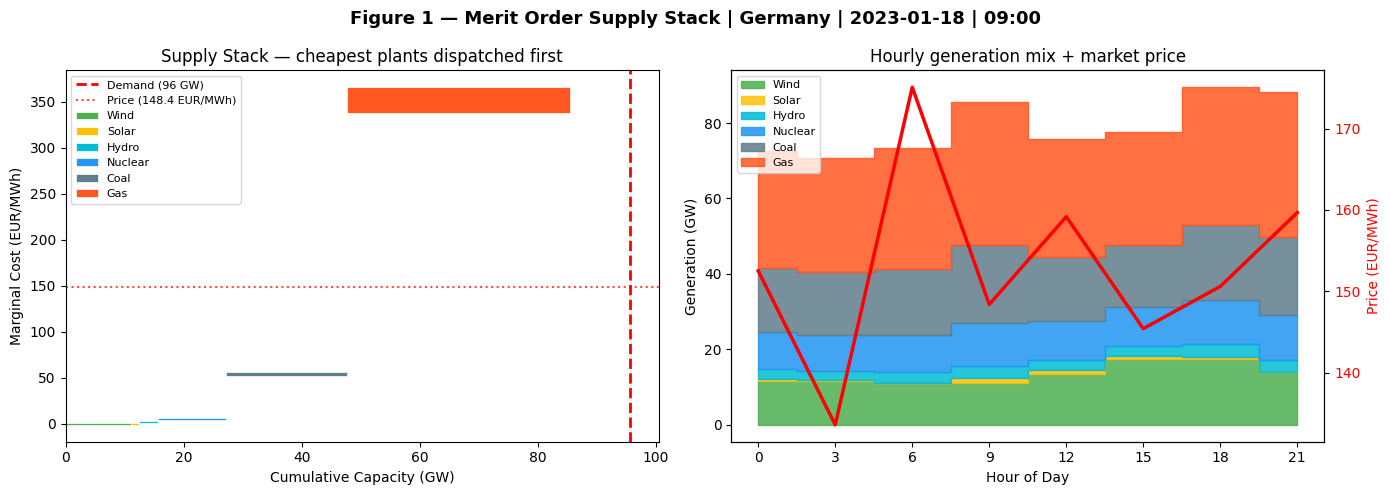

In [9]:
#  Figure 1: Merit order supply stack for one day

SAMPLE_DATE = '2023-01-18'
day = df[df['datetime'].dt.date == pd.Timestamp(SAMPLE_DATE).date()]
snap = day[day['hour'] == 9].iloc[0]   # 9am snapshot

# get commodity prices for that day and calculate costs
mc = calc_marginal_costs(snap['gas_price_eur_mwh'],
                         snap['coal_price_usd_t'],
                         snap['carbon_price_eur_t'])

# build the supply stack — sorted cheapest to costliest
fuels    = ['wind','solar','hydro','nuclear','coal','gas']
colours  = ['#4CAF50','#FFC107','#00BCD4','#2196F3','#607D8B','#FF5722']
stack    = []
cumul_mw = 0

for fuel in fuels:
    mw   = snap[f'{fuel}_mw']
    cost = mc[fuel]
    if mw > 0:
        stack.append({'fuel': fuel, 'mw': mw,
                      'cost': cost, 'start': cumul_mw, 'colour': colours[fuels.index(fuel)]})
        cumul_mw += mw

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Figure 1 — Merit Order Supply Stack | Germany | {SAMPLE_DATE} | 09:00',
             fontsize=13, fontweight='bold')

# LEFT CHART — supply stack (horizontal bar chart)
ax1 = axes[0]
for item in stack:
    ax1.barh(item['cost'], item['mw'], left=item['start'],
             color=item['colour'], height=max(2, item['cost']*0.08),
             edgecolor='white', linewidth=0.5, label=item['fuel'].capitalize())

ax1.axvline(snap['demand_mw'], color='red', linewidth=2,
            linestyle='--', label=f"Demand ({snap['demand_mw']:.0f} GW)")
ax1.axhline(snap['price_eur_mwh'], color='red', linewidth=1.5,
            linestyle=':', alpha=0.7, label=f"Price ({snap['price_eur_mwh']:.1f} EUR/MWh)")
ax1.set_xlabel('Cumulative Capacity (GW)')
ax1.set_ylabel('Marginal Cost (EUR/MWh)')
ax1.set_title('Supply Stack — cheapest plants dispatched first')
ax1.legend(fontsize=8)

# RIGHT CHART — hourly generation + price for the full day
ax2 = axes[1]
hours  = day['hour'].values
bottom = np.zeros(len(day))

for fuel, colour in zip(fuels, colours):
    vals = day[f'{fuel}_mw'].values
    ax2.fill_between(hours, bottom, bottom + vals,
                     alpha=0.85, color=colour,
                     label=fuel.capitalize(), step='mid')
    bottom += vals

ax2b = ax2.twinx()
ax2b.plot(day['hour'], day['price_eur_mwh'],
          'r-', linewidth=2.5, label='Price (EUR/MWh)')
ax2b.set_ylabel('Price (EUR/MWh)', color='red')
ax2b.tick_params(axis='y', labelcolor='red')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Generation (GW)')
ax2.set_title('Hourly generation mix + market price')
ax2.set_xticks(range(0, 24, 3))
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('fig1_merit_order.png')
plt.show()

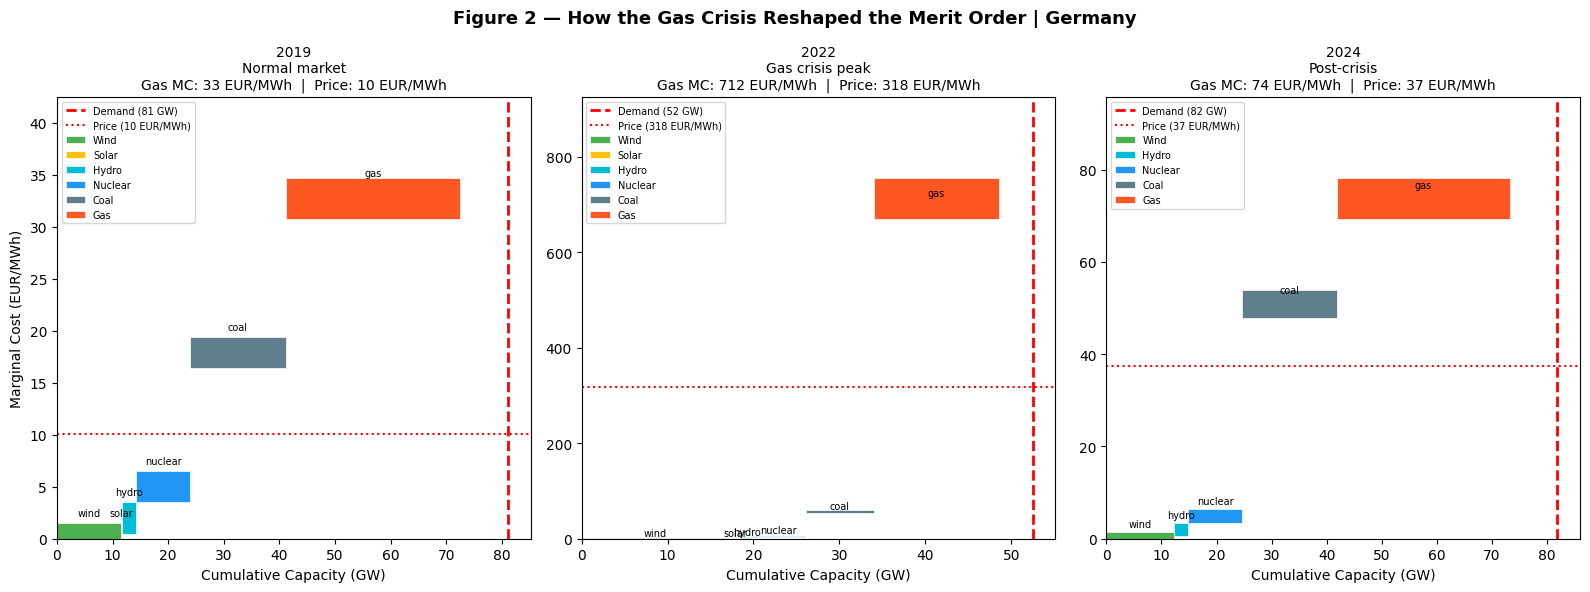

In [31]:
# Figure 2: 2019 vs 2022 vs 2024 merit order comparison

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Figure 2 — How the Gas Crisis Reshaped the Merit Order | Germany',
             fontsize=13, fontweight='bold')

years  = [2019,        2022,          2024]
dates  = ['2019-01-16','2022-09-01',  '2024-01-17']
titles = ['2019\nNormal market','2022\nGas crisis peak','2024\nPost-crisis']
fuels  = ['wind','solar','hydro','nuclear','coal','gas']
colours= ['#4CAF50','#FFC107','#00BCD4','#2196F3','#607D8B','#FF5722']

for ax, date_str, title in zip(axes, dates, titles):
    day  = df[df['datetime'].dt.date == pd.Timestamp(date_str).date()]
    if day.empty:
        ax.set_title(f'{title}\n(no data)')
        continue

    snap = day.iloc[2]
    mc   = calc_marginal_costs(snap['gas_price_eur_mwh'],
                               snap['coal_price_usd_t'],
                               snap['carbon_price_eur_t'])
    cumul = 0
    for fuel, colour in zip(fuels, colours):
        mw   = snap[f'{fuel}_mw']
        cost = mc[fuel]
        if mw > 0:
            ax.barh(cost, mw, left=cumul, color=colour,
                    height=max(3, cost * 0.12),
                    edgecolor='white', linewidth=0.5,
                    label=fuel.capitalize())
            # add fuel name label directly on each bar
            ax.text(cumul + mw/2, cost + 2, fuel,
                    ha='center', va='bottom', fontsize=7, color='black')
            cumul += mw

    ax.axvline(snap['demand_mw'],     color='red', lw=2,   ls='--',
               label=f"Demand ({snap['demand_mw']:.0f} GW)")
    ax.axhline(snap['price_eur_mwh'], color='red', lw=1.5, ls=':',
               label=f"Price ({snap['price_eur_mwh']:.0f} EUR/MWh)")

    # each panel gets its OWN y-axis scale so all fuels are visible
    ax.set_ylim(0, mc['gas'] * 1.3)

    ax.set_title(f"{title}\nGas MC: {mc['gas']:.0f} EUR/MWh  |  "
                 f"Price: {snap['price_eur_mwh']:.0f} EUR/MWh", fontsize=10)
    ax.set_xlabel('Cumulative Capacity (GW)')
    ax.legend(fontsize=7, loc='upper left')

axes[0].set_ylabel('Marginal Cost (EUR/MWh)')

plt.tight_layout()
plt.savefig('fig2_year_comparison.png')
plt.show()

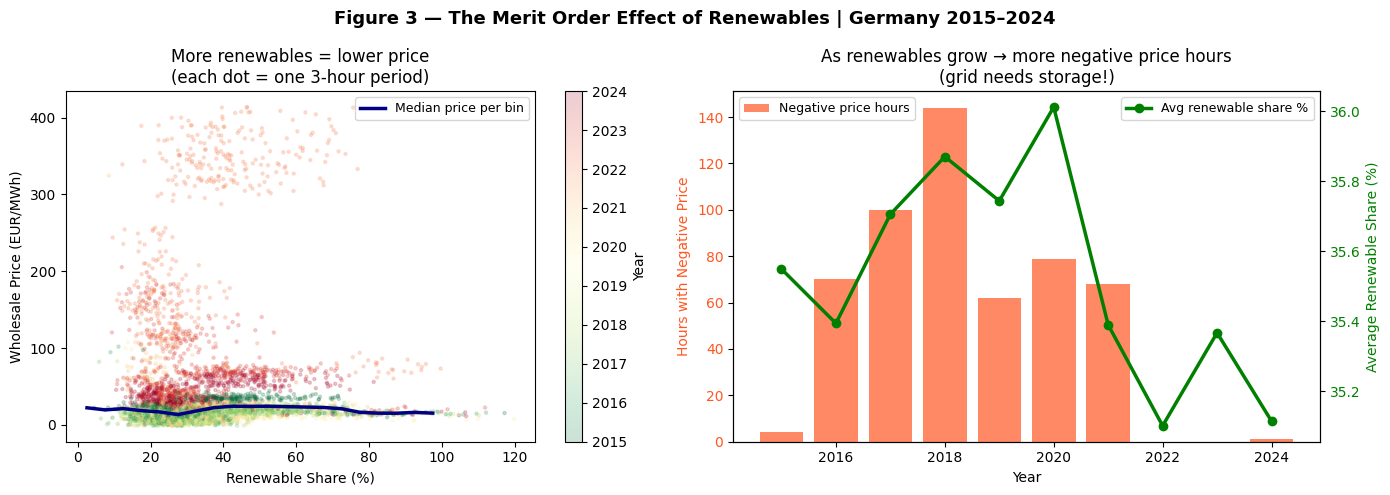

In [12]:
#  Figure 3: Renewable share vs wholesale price

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 3 — The Merit Order Effect of Renewables | Germany 2015–2024',
             fontsize=13, fontweight='bold')

# remove extreme outliers for clean visualisation
p1  = df['price_eur_mwh'].quantile(0.01)
p99 = df['price_eur_mwh'].quantile(0.99)
clean = df[(df['price_eur_mwh'] >= p1) & (df['price_eur_mwh'] <= p99)].copy()

# bin renewable share into 5% buckets, get median price per bucket
clean['renew_bin'] = pd.cut(clean['renewables_pct'], bins=range(0,105,5), right=False)
bin_stats = clean.groupby('renew_bin', observed=True)['price_eur_mwh'].median().reset_index()
bin_stats['bin_mid'] = bin_stats['renew_bin'].apply(lambda x: x.mid)

# LEFT — scatter: every hour plotted, coloured by year
ax1 = axes[0]
sample = clean.sample(5000, random_state=42)
sc = ax1.scatter(sample['renewables_pct'], sample['price_eur_mwh'],
                 c=sample['year'], cmap='RdYlGn_r', alpha=0.2, s=5)
ax1.plot(bin_stats['bin_mid'], bin_stats['price_eur_mwh'],
         'navy', linewidth=2.5, label='Median price per bin', zorder=5)
plt.colorbar(sc, ax=ax1, label='Year')
ax1.set_xlabel('Renewable Share (%)')
ax1.set_ylabel('Wholesale Price (EUR/MWh)')
ax1.set_title('More renewables = lower price\n(each dot = one 3-hour period)')
ax1.legend(fontsize=9)

# RIGHT — negative price hours per year vs renewable share growth
ax2  = axes[1]
ax2b = ax2.twinx()

neg_by_year   = df.groupby('year')['is_negative_price'].sum()
renew_by_year = df.groupby('year')['renewables_pct'].mean()

bars = ax2.bar(neg_by_year.index, neg_by_year.values,
               color='#FF5722', alpha=0.7, label='Negative price hours')
line, = ax2b.plot(renew_by_year.index, renew_by_year.values,
                  'g-o', linewidth=2.5, markersize=6, label='Avg renewable share %')

ax2.set_xlabel('Year')
ax2.set_ylabel('Hours with Negative Price', color='#FF5722')
ax2.tick_params(axis='y', labelcolor='#FF5722')
ax2b.set_ylabel('Average Renewable Share (%)', color='green')
ax2b.tick_params(axis='y', labelcolor='green')
ax2.set_title('As renewables grow → more negative price hours\n(grid needs storage!)')
ax2.legend(loc='upper left', fontsize=9)
ax2b.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('fig3_renewable_effect.png')
plt.show()

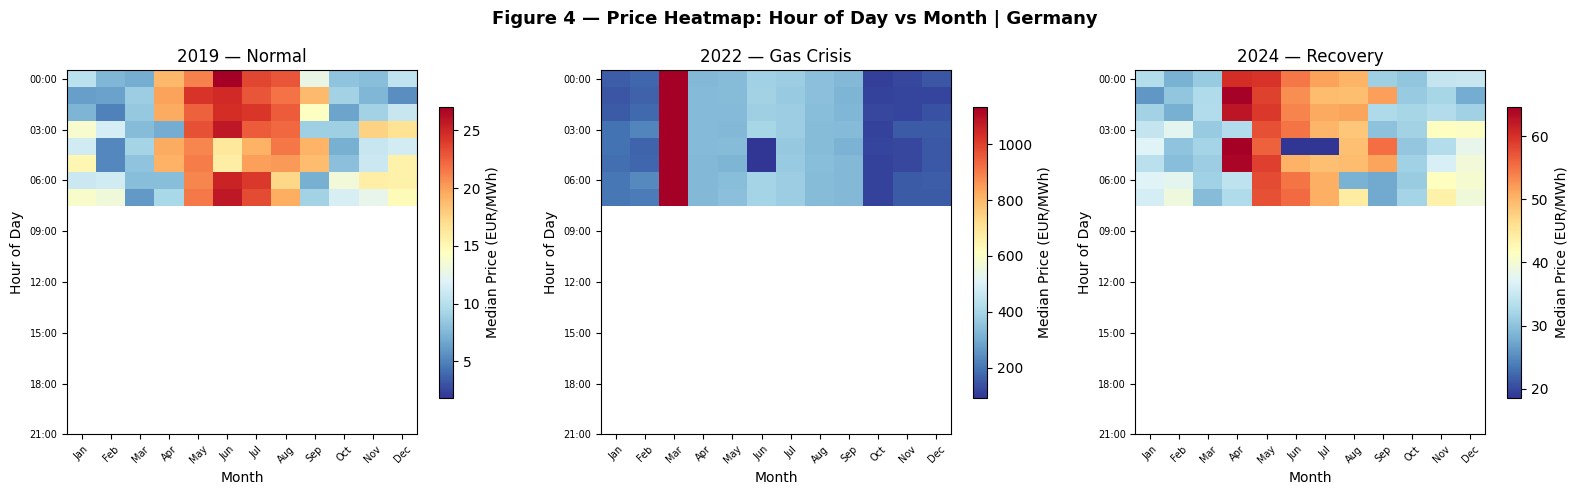

In [13]:
#  Figure 4: Price heatmap by hour and month

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 4 — Price Heatmap: Hour of Day vs Month | Germany',
             fontsize=13, fontweight='bold')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

for ax, yr, title in zip(axes,
                          [2019, 2022, 2024],
                          ['2019 — Normal','2022 — Gas Crisis','2024 — Recovery']):
    yr_data = df[df['year'] == yr].copy()
    pivot   = yr_data.pivot_table(values='price_eur_mwh',
                                   index='hour', columns='month',
                                   aggfunc='median')
    vmin = yr_data['price_eur_mwh'].quantile(0.05)
    vmax = yr_data['price_eur_mwh'].quantile(0.95)

    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlBu_r',
                   vmin=vmin, vmax=vmax, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Median Price (EUR/MWh)', shrink=0.8)
    ax.set_xticks(range(12))
    ax.set_xticklabels(month_labels, fontsize=7, rotation=45)
    ax.set_yticks(range(0, 24, 3))
    ax.set_yticklabels([f'{h:02d}:00' for h in range(0,24,3)], fontsize=7)
    ax.set_xlabel('Month')
    ax.set_ylabel('Hour of Day')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('fig4_price_heatmap.png')
plt.show()

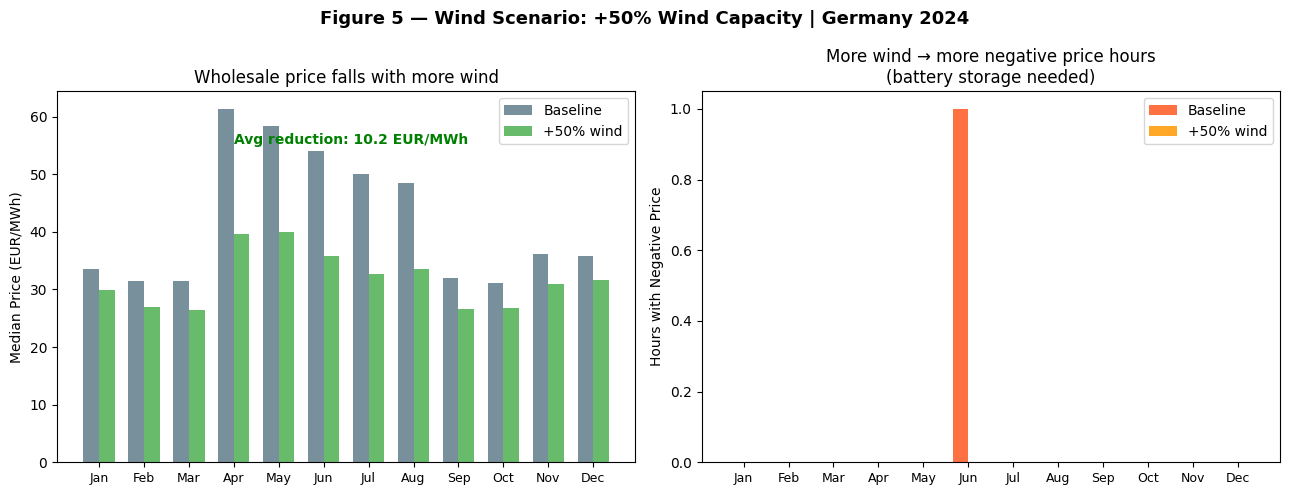

In [14]:
# Figure 5: Wind scenario (+50% wind capacity)

base = df[df['year'] == 2024].copy()

base['wind_scenario']       = base['wind_mw'] * 1.5
base['net_demand_base']     = (base['demand_mw'] - base['wind_mw'] - base['solar_mw']).clip(lower=0.1)
base['net_demand_scenario'] = (base['demand_mw'] - base['wind_scenario'] - base['solar_mw']).clip(lower=0)
demand_ratio                = (base['net_demand_scenario'] / base['net_demand_base']).clip(upper=1.0)
base['price_scenario']      = (base['price_eur_mwh'] * demand_ratio).clip(lower=-50)

monthly = base.groupby('month').agg(
    price_base     = ('price_eur_mwh',  'median'),
    price_scenario = ('price_scenario', 'median'),
    neg_base       = ('is_negative_price', 'sum')
).reset_index()
monthly['neg_scenario'] = (base['price_scenario'] < 0).groupby(base['month']).sum().values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 5 — Wind Scenario: +50% Wind Capacity | Germany 2024',
             fontsize=13, fontweight='bold')

x, w = np.arange(12), 0.35

ax1 = axes[0]
ax1.bar(x - w/2, monthly['price_base'],     w, color='#607D8B', alpha=0.85, label='Baseline')
ax1.bar(x + w/2, monthly['price_scenario'], w, color='#4CAF50', alpha=0.85, label='+50% wind')
ax1.set_xticks(x)
ax1.set_xticklabels(month_labels, fontsize=9)
ax1.set_ylabel('Median Price (EUR/MWh)')
ax1.set_title('Wholesale price falls with more wind')
ax1.legend()
reduction = (monthly['price_base'] - monthly['price_scenario']).mean()
ax1.annotate(f'Avg reduction: {reduction:.1f} EUR/MWh',
             xy=(3, monthly['price_base'].max() * 0.9),
             fontsize=10, color='green', fontweight='bold')

ax2 = axes[1]
ax2.bar(x - w/2, monthly['neg_base'],     w, color='#FF5722', alpha=0.85, label='Baseline')
ax2.bar(x + w/2, monthly['neg_scenario'], w, color='#FF9800', alpha=0.85, label='+50% wind')
ax2.set_xticks(x)
ax2.set_xticklabels(month_labels, fontsize=9)
ax2.set_ylabel('Hours with Negative Price')
ax2.set_title('More wind → more negative price hours\n(battery storage needed)')
ax2.legend()

plt.tight_layout()
plt.savefig('fig5_wind_scenario.png')
plt.show()